# Exploratory Data Analysis (EDA)
## Project: Product Placement Optimisation
### Purpose: Visualize patterns in clean data before running ML algorithms
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project
### Input: data/processed/sales_data_cleaned.csv
### Output: 9 charts saved to reports/figures/

## Charts Planned

1. Top 20 products by sales count
2. Category distribution
3. Top 20 products by revenue
4. Basket value distribution (shows our baseline KPI)
5. Items per basket distribution
6. Categories per basket
7. Category co-occurrence heatmap (KEY chart for placement)
8. Top product pairs bought together
9. Basket size segmentation (small, medium and large value baskets)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

print("Libraries loaded!")
print(f"Figures will be saved to: {figures_path}")

Libraries loaded!
Figures will be saved to: D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures


## Load Cleaned Data

In [2]:
df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Categories: {df['category'].nunique()}")
print(f"Invoices: {df['invoice_no'].nunique():,}")

Data loaded successfully!
Shape: (767180, 14)
Categories: 25
Invoices: 218,037


## Chart 1: Top 20 Products by Sales Count

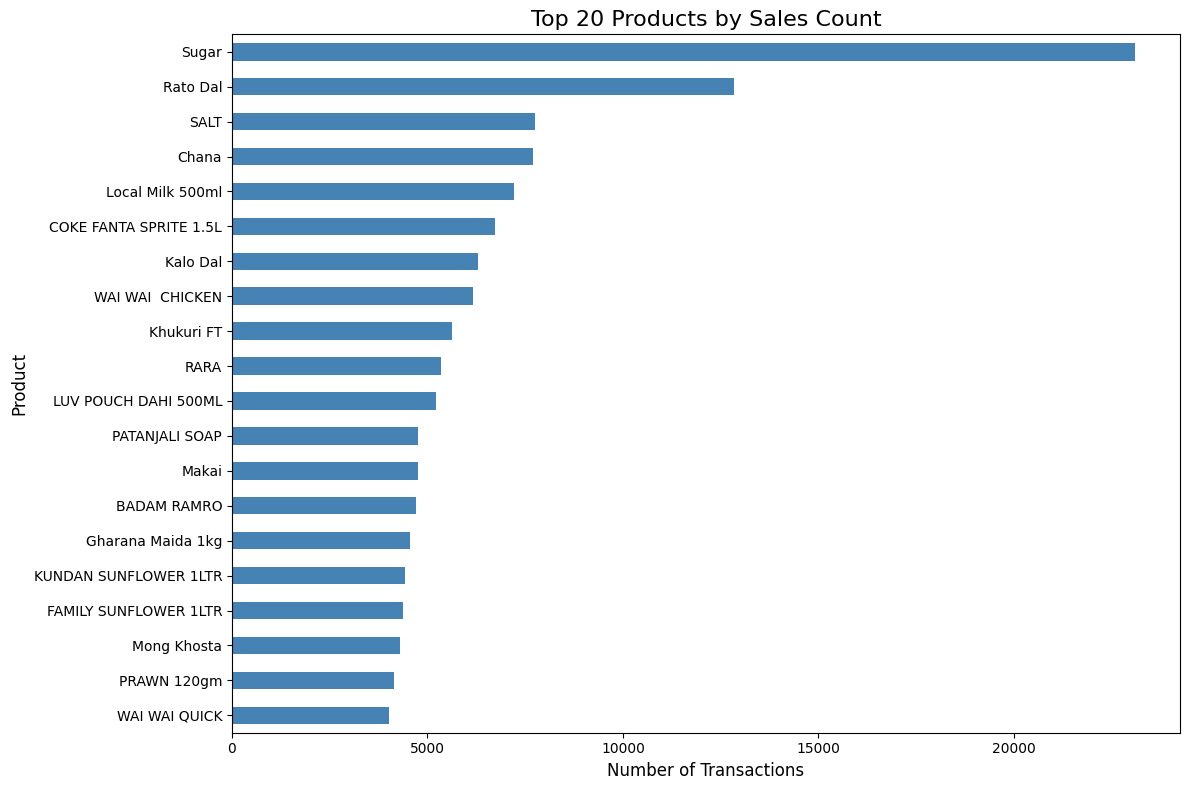

Chart 1 saved!


In [3]:
top_products = df['product'].value_counts().head(20)

plt.figure(figsize=(12, 8))
top_products.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Products by Sales Count', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart1_top20_products_count.png'), dpi=150)
plt.show()
print("Chart 1 saved!")

### Finding: Chart 1 - Top 20 Products by Sales Count

Sugar, Salt, and Dal products appear in the most transactions across the store. These are daily household essentials that customers buy on almost every visit. High transaction count means these products drive foot traffic into the store. They should be placed strategically, not at the entrance, because customers will walk the entire store to find them anyway.Sugar appears in 23,083 transactions, Rato Dal in 12,533 and SALT in 7,756. These are the three products that anchor the store's daily traffic.

## Chart 2: Category Distribution

Top 5 categories by basket penetration:
                           line_items  pct_of_line_items  baskets  pct_of_baskets
category                                                                         
FOOD STAPLES                   179081              23.34    91988           42.19
CANNED AND PACKAGED FOODS       98597              12.85    62371           28.61
BISCUITS AND COOKIES            47036               6.13    33209           15.23
TEA AND SPICES                  45517               5.93    32978           15.12
COOKING OIL                     37249               4.86    32926           15.10

FOOD STAPLES appears in 91,988 of 218,037 baskets (42.19% of baskets)
FOOD STAPLES accounts for 179,081 of 767,180 line items (23.34% of line items)


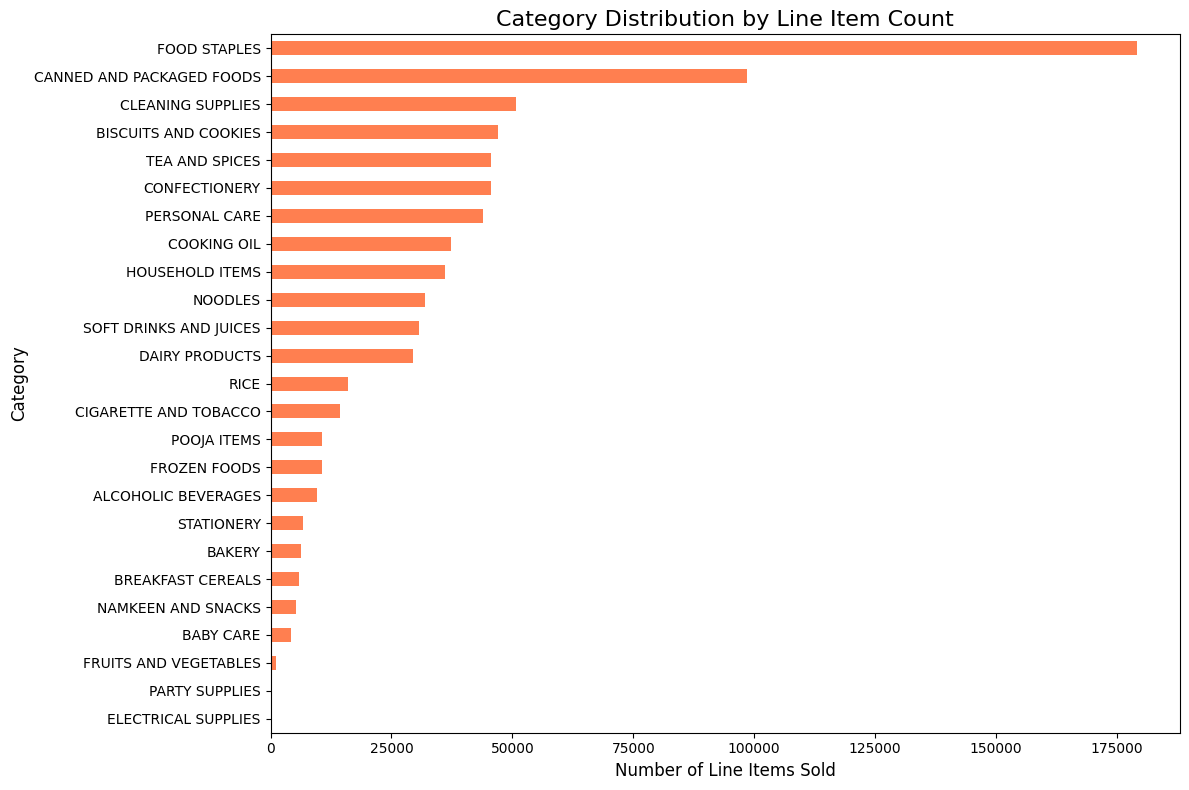

Chart 2 saved!


In [4]:
# NOTE ON WHAT THIS COUNTS.
# value_counts() counts LINE ITEMS (rows), not baskets. One basket containing
# three FOOD STAPLES products contributes three rows here but only one basket.
# Both measures are printed below so the two are never confused: the line-item
# share and the basket penetration are different numbers and answer different
# questions. Basket penetration is the one that matters for placement, because
# placement is about how many shopping trips pass a category.
category_counts = df['category'].value_counts()

total_line_items = len(df)
total_baskets = df['invoice_no'].nunique()
baskets_per_category = df.groupby('category')['invoice_no'].nunique()

category_summary = pd.DataFrame({
    'line_items': category_counts,
    'pct_of_line_items': (category_counts / total_line_items * 100).round(2),
    'baskets': baskets_per_category,
    'pct_of_baskets': (baskets_per_category / total_baskets * 100).round(2),
}).sort_values('pct_of_baskets', ascending=False)

print("Top 5 categories by basket penetration:")
print(category_summary.head(5).to_string())
print()
print(f"FOOD STAPLES appears in {category_summary.loc['FOOD STAPLES', 'baskets']:,.0f} "
      f"of {total_baskets:,} baskets "
      f"({category_summary.loc['FOOD STAPLES', 'pct_of_baskets']}% of baskets)")
print(f"FOOD STAPLES accounts for {category_summary.loc['FOOD STAPLES', 'line_items']:,.0f} "
      f"of {total_line_items:,} line items "
      f"({category_summary.loc['FOOD STAPLES', 'pct_of_line_items']}% of line items)")

plt.figure(figsize=(12, 8))
category_counts.sort_values().plot(kind='barh', color='coral')
plt.title('Category Distribution by Line Item Count', fontsize=16)
plt.xlabel('Number of Line Items Sold', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart2_category_distribution.png'), dpi=150)
plt.show()
print("Chart 2 saved!")

### Finding: Chart 2 - Category Distribution

FOOD STAPLES is the anchor category of the entire store. Two different measures say so, and it is worth stating both because they are easy to confuse:

- **Basket penetration: 42.19%.** FOOD STAPLES appears in 91,988 of the 218,037 baskets. Roughly two in every five shopping trips include it.
- **Line item share: 23.34%.** FOOD STAPLES accounts for 179,081 of the 767,180 individual lines sold.

The chart above plots the second measure, line items, because it counts every product sold rather than every trip. **Basket penetration is the measure that matters for placement**, because a placement decision is about how many shopping trips walk past a category, not how many individual items get scanned. 42.19% is therefore the figure used in notebooks 04 and 06 and in the dashboard.

CLEANING SUPPLIES and COOKING OIL follow, and together with FOOD STAPLES these categories cover the majority of customer visits. In retail design, anchor categories like this are placed at the back or centre of the store so customers pass other products on the way to them.

## Chart 3: Top 20 Products by Revenue

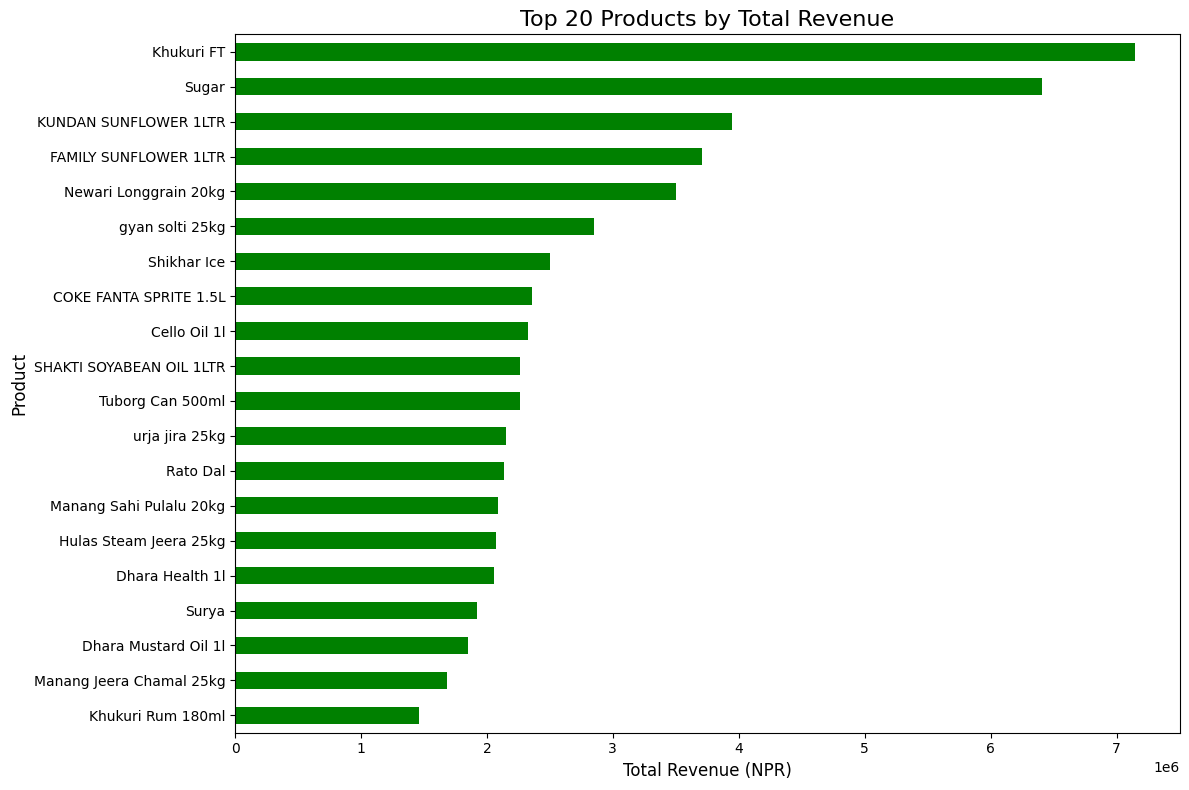

Chart 3 saved!


In [5]:
top_revenue = df.groupby('product')['total_amount'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
top_revenue.sort_values().plot(kind='barh', color='green')
plt.title('Top 20 Products by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue (NPR)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart3_top20_products_revenue.png'), dpi=150)
plt.show()
print("Chart 3 saved!")

In [6]:
print("TOP 10 PRODUCTS BY REVENUE:")
print("=" * 50)
for product, revenue in top_revenue.head(10).items():
    print(f"  {product:<40} Rs {revenue:>12,.0f}")

TOP 10 PRODUCTS BY REVENUE:
  Khukuri FT                               Rs    7,146,783
  Sugar                                    Rs    6,410,812
  KUNDAN SUNFLOWER 1LTR                    Rs    3,944,879
  FAMILY SUNFLOWER 1LTR                    Rs    3,708,456
  Newari Longgrain 20kg                    Rs    3,498,057
  gyan solti 25kg                          Rs    2,847,104
  Shikhar Ice                              Rs    2,498,048
  COKE FANTA SPRITE 1.5L                   Rs    2,356,686
  Cello Oil 1l                             Rs    2,324,655
  SHAKTI SOYABEAN OIL 1LTR                 Rs    2,261,857


### Finding: Chart 3 - Top 20 Products by Revenue

The top revenue products are not always the same as the top frequency products. Rice, Cooking Oil and premium Dal varieties generate the most revenue even though they are not always the most frequent. This matters for placement because high revenue products deserve prominent shelf space, not just high frequency ones.

## Chart 4: Basket Value Distribution

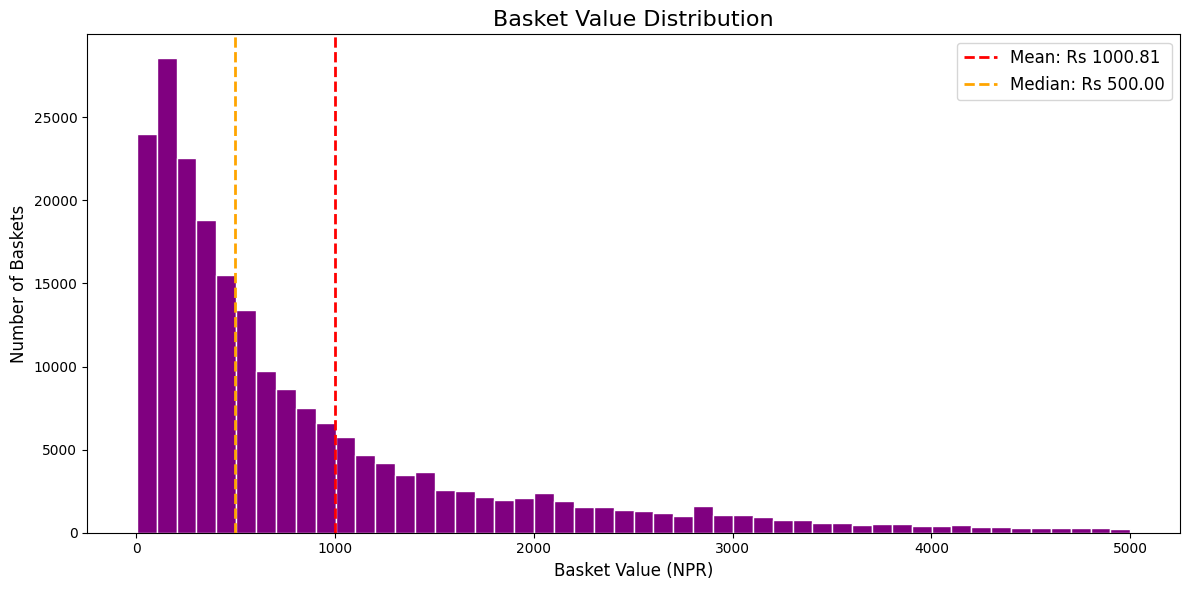

Chart 4 saved!
Mean basket value: Rs 1000.81
Median basket value: Rs 500.00


In [7]:
basket_values = df.groupby('invoice_no')['total_amount'].sum()

plt.figure(figsize=(12, 6))
plt.hist(basket_values[basket_values <= 5000], bins=50, color='purple', edgecolor='white')
plt.axvline(basket_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: Rs {basket_values.mean():.2f}')
plt.axvline(basket_values.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: Rs {basket_values.median():.2f}')
plt.title('Basket Value Distribution', fontsize=16)
plt.xlabel('Basket Value (NPR)', fontsize=12)
plt.ylabel('Number of Baskets', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart4_basket_value_distribution.png'), dpi=150)
plt.show()
print(f"Chart 4 saved!")
print(f"Mean basket value: Rs {basket_values.mean():.2f}")
print(f"Median basket value: Rs {basket_values.median():.2f}")

### Finding: Chart 4 - Basket Value Distribution

The distribution is heavily right skewed. Most customers spend under Rs 500 per visit but a small number of very large baskets pull the average up. The key numbers are:
- Mean basket value: Rs 1,000.81 (our primary KPI target)
- Median basket value: Rs 500.00 (what a typical customer actually spends)

The gap between mean and median tells us that a small group of high value customers significantly impact total revenue. If we can nudge median customers from Rs 500 to Rs 550 through better product placement, the revenue impact across 218,037 transactions is very large.

## Chart 5: Items Per Basket Distribution

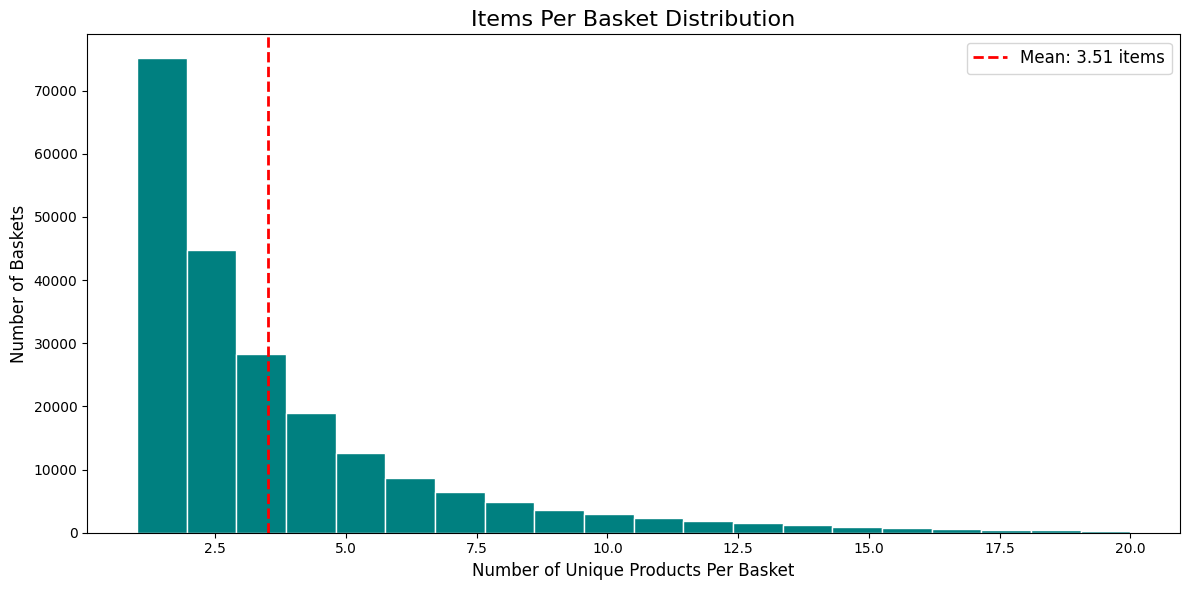

Chart 5 saved!
Mean items per basket: 3.51
Single item baskets: 75,168


In [8]:
items_per_basket = df.groupby('invoice_no')['product'].nunique()

plt.figure(figsize=(12, 6))
plt.hist(items_per_basket[items_per_basket <= 20], bins=20, color='teal', edgecolor='white')
plt.axvline(items_per_basket.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {items_per_basket.mean():.2f} items')
plt.title('Items Per Basket Distribution', fontsize=16)
plt.xlabel('Number of Unique Products Per Basket', fontsize=12)
plt.ylabel('Number of Baskets', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart5_items_per_basket.png'), dpi=150)
plt.show()
print(f"Chart 5 saved!")
print(f"Mean items per basket: {items_per_basket.mean():.2f}")
print(f"Single item baskets: {(items_per_basket == 1).sum():,}")

### Finding: Chart 5 - Items Per Basket

Most customers buy between 1 and 5 unique products per visit. The mean is 3.51 items per basket. This means most shopping trips are quick top-up visits, not full weekly shops. For placement, this means products that are naturally bought together must be physically close because customers are not browsing the whole store.

## Chart 6: Categories Per Basket

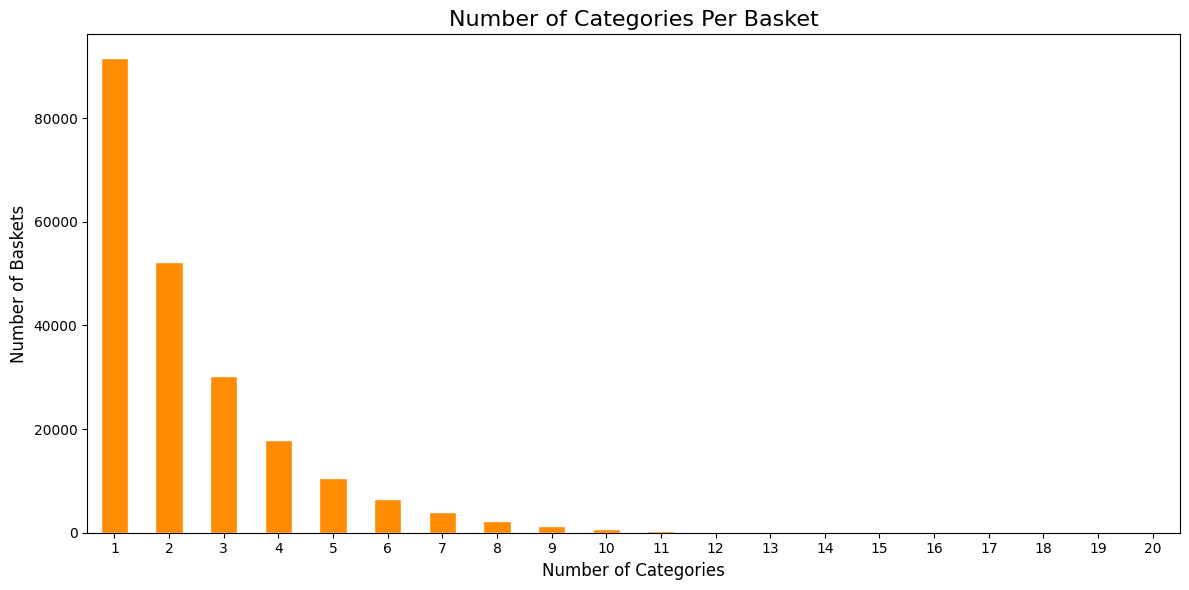

Chart 6 saved!
Mean categories per basket: 2.40
Baskets with only 1 category: 91,607
Baskets with 3+ categories: 74,160


In [9]:
categories_per_basket = df.groupby('invoice_no')['category'].nunique()

plt.figure(figsize=(12, 6))
categories_per_basket.value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Number of Categories Per Basket', fontsize=16)
plt.xlabel('Number of Categories', fontsize=12)
plt.ylabel('Number of Baskets', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart6_categories_per_basket.png'), dpi=150)
plt.show()
print("Chart 6 saved!")
print(f"Mean categories per basket: {categories_per_basket.mean():.2f}")
print(f"Baskets with only 1 category: {(categories_per_basket == 1).sum():,}")
print(f"Baskets with 3+ categories: {(categories_per_basket >= 3).sum():,}")

### Finding: Chart 6 - Categories Per Basket

Most baskets contain only 1 or 2 categories. This confirms that customers come in for a specific purpose, not to browse. When a customer does buy from 2 or more categories, those category combinations are valuable intelligence for placement. The association rules in notebook 05 will mine exactly these combinations.

## Chart 7: Category Co-occurrence Heatmap

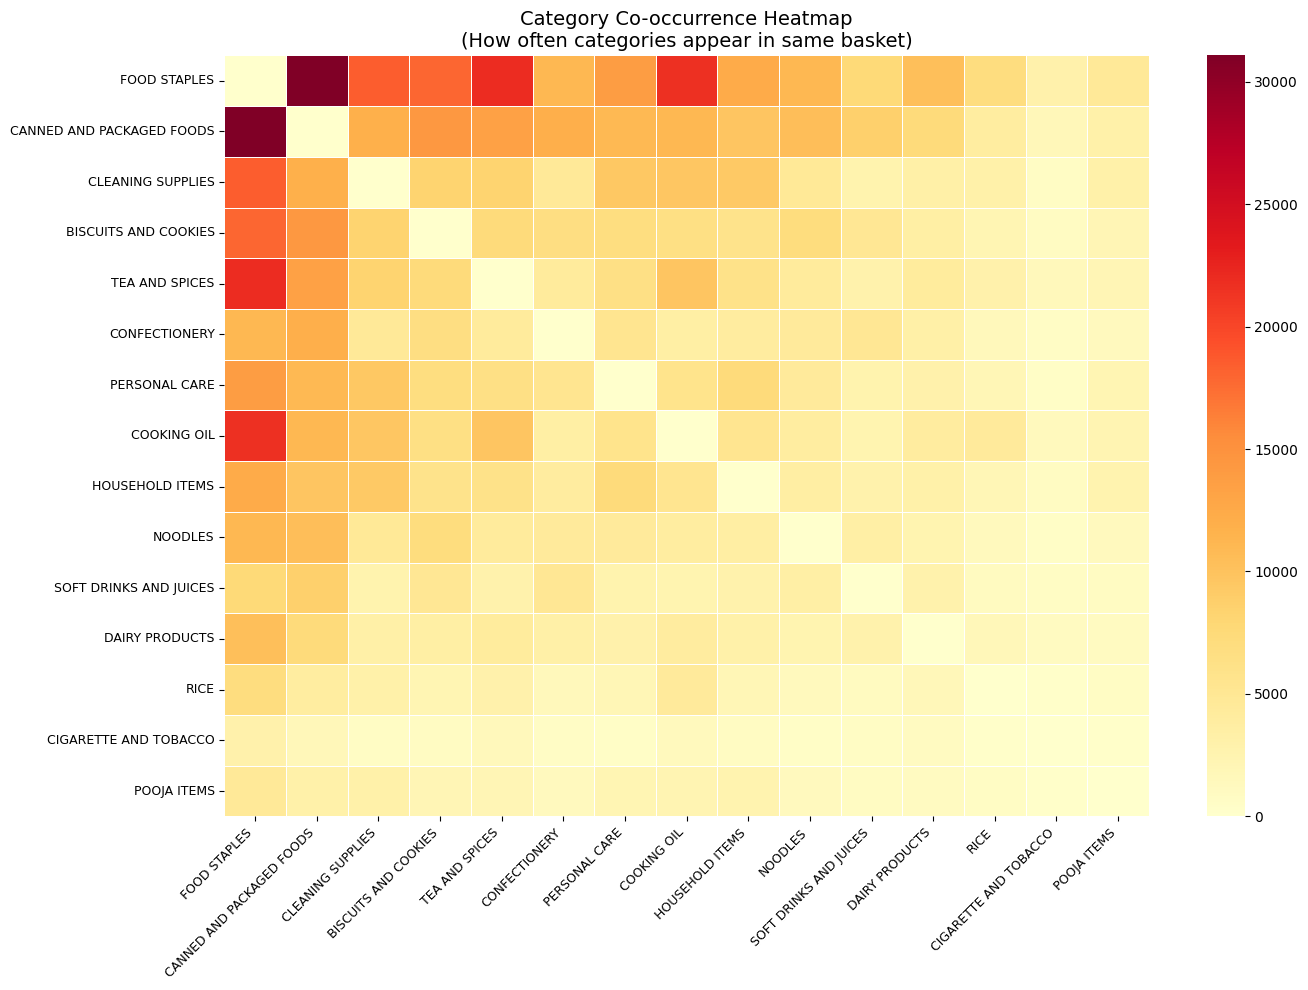

Chart 7 saved!


In [10]:
from itertools import combinations

basket_categories = df.groupby('invoice_no')['category'].apply(set)

co_occur = {}
for basket in basket_categories:
    for cat1, cat2 in combinations(sorted(basket), 2):
        pair = (cat1, cat2)
        co_occur[pair] = co_occur.get(pair, 0) + 1

top_categories = df['category'].value_counts().head(15).index.tolist()

matrix = pd.DataFrame(0, index=top_categories, columns=top_categories)

for (cat1, cat2), count in co_occur.items():
    if cat1 in top_categories and cat2 in top_categories:
        matrix.loc[cat1, cat2] = count
        matrix.loc[cat2, cat1] = count

plt.figure(figsize=(14, 10))
sns.heatmap(matrix, annot=False, cmap='YlOrRd', linewidths=0.5)
plt.title('Category Co-occurrence Heatmap\n(How often categories appear in same basket)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart7_category_cooccurrence_heatmap.png'), dpi=150)
plt.show()
print("Chart 7 saved!")

### Finding: Chart 7 - Category Co-occurrence Heatmap

This is the most important chart for placement decisions. The darker the cell, the more often those two categories appear in the same basket. FOOD STAPLES and CANNED AND PACKAGED FOODS show the strongest co-occurrence. CLEANING SUPPLIES appears as a strong connector across many category pairs. This heatmap is the visual foundation for the placement zones defined in notebook 07.

## Chart 8: Top Product Pairs Bought Together

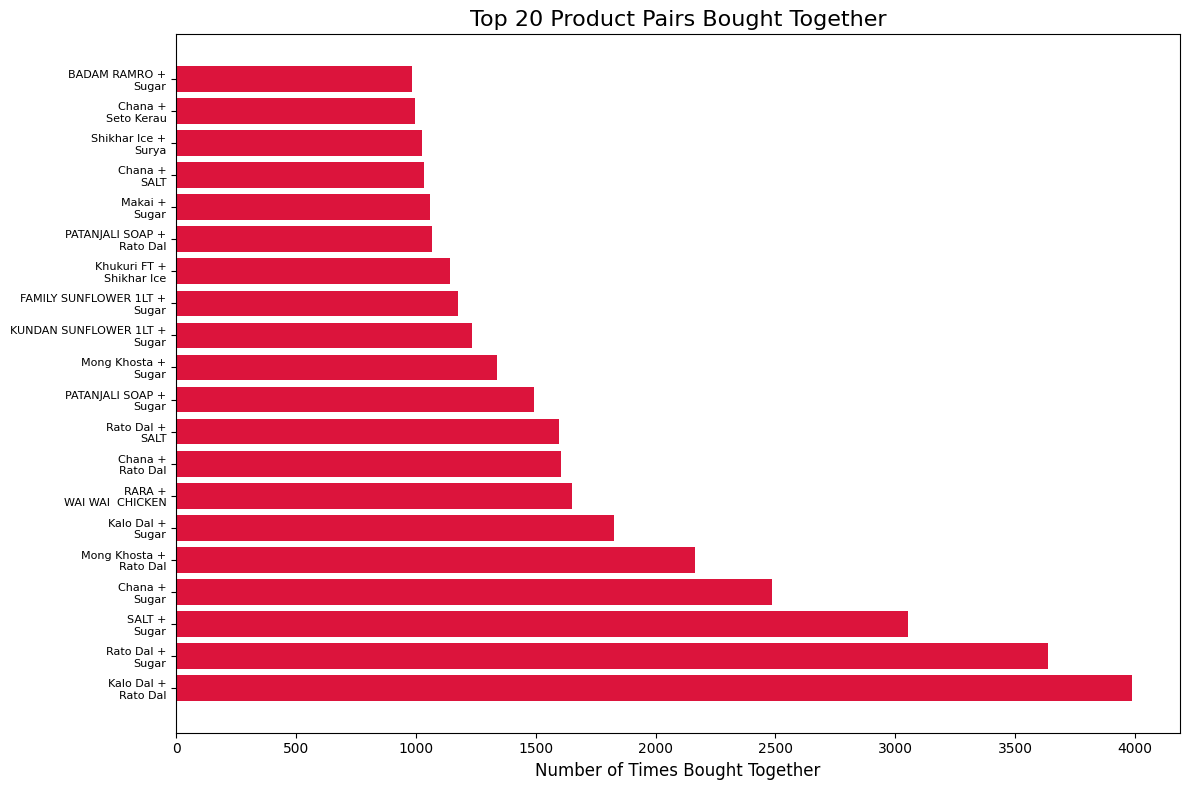

Chart 8 saved!

Top 10 product pairs:
           product_1         product_2  count
93          Kalo Dal          Rato Dal   3989
109         Rato Dal             Sugar   3639
1905            SALT             Sugar   3055
400            Chana             Sugar   2485
1722     Mong Khosta          Rato Dal   2164
106         Kalo Dal             Sugar   1825
926             RARA  WAI WAI  CHICKEN   1653
1581           Chana          Rato Dal   1605
2338        Rato Dal              SALT   1596
1277  PATANJALI SOAP             Sugar   1494


In [11]:
from itertools import combinations

basket_products = df.groupby('invoice_no')['product'].apply(set)

product_pairs = {}
for basket in basket_products:
    if len(basket) >= 2:
        for prod1, prod2 in combinations(sorted(basket), 2):
            pair = (prod1, prod2)
            product_pairs[pair] = product_pairs.get(pair, 0) + 1

pairs_df = pd.DataFrame([
    {'product_1': p1, 'product_2': p2, 'count': count}
    for (p1, p2), count in product_pairs.items()
]).sort_values('count', ascending=False).head(20)

plt.figure(figsize=(12, 8))
pair_labels = [f"{row['product_1'][:20]} +\n{row['product_2'][:20]}" 
               for _, row in pairs_df.iterrows()]
plt.barh(range(len(pairs_df)), pairs_df['count'], color='crimson')
plt.yticks(range(len(pairs_df)), pair_labels, fontsize=8)
plt.title('Top 20 Product Pairs Bought Together', fontsize=16)
plt.xlabel('Number of Times Bought Together', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart8_top_product_pairs.png'), dpi=150)
plt.show()
print("Chart 8 saved!")
print("\nTop 10 product pairs:")
print(pairs_df[['product_1', 'product_2', 'count']].head(10).to_string())

### Finding: Chart 8 - Top Product Pairs Bought Together

Kalo Dal and Rato Dal are bought together 3,989 times, the strongest product pair in the entire dataset. Dal, Sugar and Salt consistently appear as a cluster. These are not random patterns, they reflect how Nepali households cook. Products in these pairs should be within arm's reach of each other on the shelf.

## Chart 9: Basket Size Segmentation

Baskets are split into three value segments to understand the different types of shopping trip:

- Small: under Rs 500
- Medium: Rs 500 to 2000
- Large: above Rs 2000

For each segment we count how many baskets fall into it and identify the top 5 most common categories bought in that segment. This shows whether quick top-up trips and large stock-up trips are driven by different products, which directly affects where those products should be placed in the store.

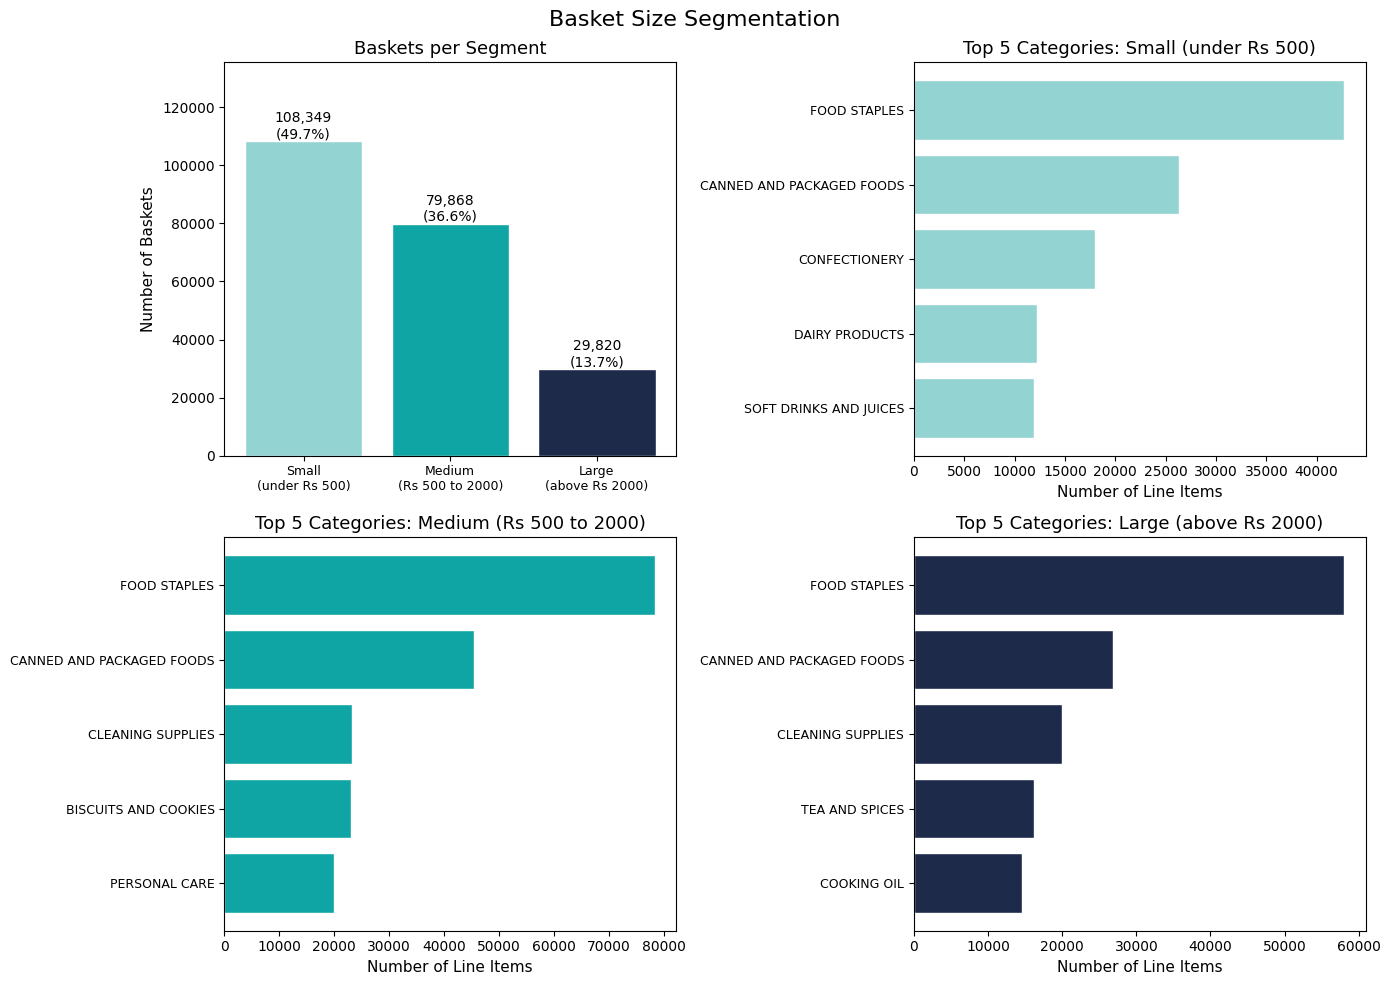

Chart 9 saved!

BASKET SEGMENTATION SUMMARY
Small (under Rs 500):
  Baskets: 108,349 (49.7% of all baskets)
  Revenue: Rs 24,822,607 (11.4% of total revenue)
  Average basket value: Rs 229.10
Medium (Rs 500 to 2000):
  Baskets: 79,868 (36.6% of all baskets)
  Revenue: Rs 79,767,736 (36.6% of total revenue)
  Average basket value: Rs 998.74
Large (above Rs 2000):
  Baskets: 29,820 (13.7% of all baskets)
  Revenue: Rs 113,624,113 (52.1% of total revenue)
  Average basket value: Rs 3,810.33


In [12]:
basket_values = df.groupby('invoice_no')['total_amount'].sum()

def basket_segment(value):
    if value < 500:
        return 'Small (under Rs 500)'
    elif value <= 2000:
        return 'Medium (Rs 500 to 2000)'
    else:
        return 'Large (above Rs 2000)'

basket_segments = basket_values.apply(basket_segment)
segment_order = ['Small (under Rs 500)', 'Medium (Rs 500 to 2000)', 'Large (above Rs 2000)']
segment_colors = ['#93D3D2', '#0EA5A4', '#1E2A4A']

segment_counts = basket_segments.value_counts().reindex(segment_order)
segment_revenue = basket_values.groupby(basket_segments).sum().reindex(segment_order)
segment_avg_value = basket_values.groupby(basket_segments).mean().reindex(segment_order)
total_revenue = basket_values.sum()

df_segmented = df.merge(basket_segments.rename('segment'), left_on='invoice_no', right_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
x_pos = range(len(segment_order))
bars = ax.bar(x_pos, segment_counts.values, color=segment_colors, edgecolor='white')
for bar, count in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{count:,}\n({count / len(basket_segments) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_xticks(list(x_pos), labels=['Small\n(under Rs 500)', 'Medium\n(Rs 500 to 2000)', 'Large\n(above Rs 2000)'], fontsize=9)
ax.set_title('Baskets per Segment', fontsize=13)
ax.set_ylabel('Number of Baskets', fontsize=11)
ax.set_ylim(0, segment_counts.max() * 1.25)

for ax, seg, color in zip([axes[0, 1], axes[1, 0], axes[1, 1]], segment_order, segment_colors):
    top5 = df_segmented[df_segmented['segment'] == seg]['category'].value_counts().head(5)
    ax.barh(list(top5.index[::-1]), top5.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 5 Categories: {seg}', fontsize=13)
    ax.set_xlabel('Number of Line Items', fontsize=11)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('Basket Size Segmentation', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart9_basket_segmentation.png'), dpi=150)
plt.show()
print("Chart 9 saved!")

print()
print("BASKET SEGMENTATION SUMMARY")
print("=" * 60)
for seg in segment_order:
    print(f"{seg}:")
    print(f"  Baskets: {segment_counts[seg]:,} ({segment_counts[seg] / len(basket_segments) * 100:.1f}% of all baskets)")
    print(f"  Revenue: Rs {segment_revenue[seg]:,.0f} ({segment_revenue[seg] / total_revenue * 100:.1f}% of total revenue)")
    print(f"  Average basket value: Rs {segment_avg_value[seg]:,.2f}")

### Finding: Chart 9 - Basket Size Segmentation

Half of all shopping trips are small. 108,349 baskets (49.7%) are under Rs 500, yet they produce only 11.4% of revenue (Rs 24.8 million). At the other end, just 29,820 large baskets (13.7%) above Rs 2000 generate 52.1% of total revenue (Rs 113.6 million), averaging Rs 3,810 per basket.

The three segments behave differently:

- Small baskets are quick top-up trips. Alongside staples, their top categories include CONFECTIONERY, DAIRY PRODUCTS and SOFT DRINKS AND JUICES. These grab-and-go categories belong near the entrance and checkout where small-basket customers actually walk.
- Medium baskets add household shopping. CLEANING SUPPLIES, BISCUITS AND COOKIES and PERSONAL CARE join the staples.
- Large baskets are monthly stock-up trips. CLEANING SUPPLIES, TEA AND SPICES and COOKING OIL appear in bulk alongside staples.

FOOD STAPLES and CANNED AND PACKAGED FOODS top every segment, confirming them as the anchor categories of the store. The placement implication is that protecting the large stock-up trip matters most, because 13.7% of customers deliver more than half of all revenue. Clustering CLEANING SUPPLIES, TEA AND SPICES and COOKING OIL near the staples zone serves exactly this group, which is what the optimised layout in notebook 07 does.

## Chart 10: ABC Analysis of Products

ABC analysis is a classic retail framework for prioritising stock management effort. Products are ranked by revenue and split into three classes: A products are the small group at the top that generate the first 70% of revenue (classically around the top 20% of products), B products are the next tier contributing the following 20% of revenue (roughly the next 30% of products), and C products are the long tail contributing the final 10% (often around half of all products). The store owner cannot watch 5,681 products equally, so this framework identifies which products deserve constant stock monitoring and which need only minimal attention.

ABC ANALYSIS SUMMARY
Class A (first 70% of revenue):
  Products: 342 (6.0% of all 5,680 products)
  Revenue: Rs 152,718,511 (70.0% of total revenue)
Class B (next 20% of revenue):
  Products: 1,065 (18.8% of all 5,680 products)
  Revenue: Rs 43,662,417 (20.0% of total revenue)
Class C (final 10% of revenue):
  Products: 4,273 (75.2% of all 5,680 products)
  Revenue: Rs 21,833,529 (10.0% of total revenue)


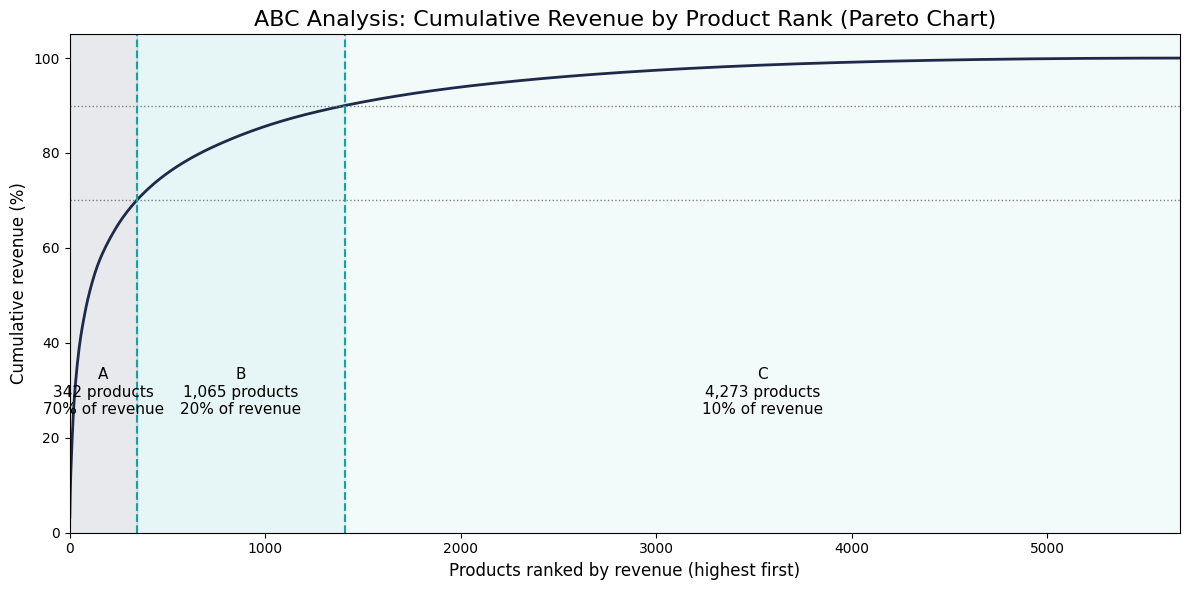

Chart 10 saved!


In [13]:
product_revenue = df.groupby('product')['total_amount'].sum().sort_values(ascending=False)
total_products = len(product_revenue)
total_product_revenue = product_revenue.sum()
cumulative_pct = product_revenue.cumsum() / total_product_revenue * 100

def abc_class(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

abc_category = cumulative_pct.apply(abc_class)

abc_df = pd.DataFrame({
    'product': product_revenue.index,
    'revenue': product_revenue.values,
    'cumulative_pct': cumulative_pct.values,
    'abc_category': abc_category.values
})

print("ABC ANALYSIS SUMMARY")
print("=" * 60)
for cat, desc in [('A', 'first 70% of revenue'),
                  ('B', 'next 20% of revenue'),
                  ('C', 'final 10% of revenue')]:
    subset = abc_df[abc_df['abc_category'] == cat]
    revenue_share = subset['revenue'].sum() / total_product_revenue * 100
    print(f"Class {cat} ({desc}):")
    print(f"  Products: {len(subset):,} ({len(subset) / total_products * 100:.1f}% of all {total_products:,} products)")
    print(f"  Revenue: Rs {subset['revenue'].sum():,.0f} ({revenue_share:.1f}% of total revenue)")

a_count = int((abc_category == 'A').sum())
b_count = int((abc_category == 'B').sum())
c_count = total_products - a_count - b_count

fig, ax = plt.subplots(figsize=(12, 6))
ranks = np.arange(1, total_products + 1)
ax.plot(ranks, cumulative_pct.values, color='#1E2A4A', linewidth=2)

ax.axvspan(0, a_count, color='#1E2A4A', alpha=0.10)
ax.axvspan(a_count, a_count + b_count, color='#0EA5A4', alpha=0.10)
ax.axvspan(a_count + b_count, total_products, color='#93D3D2', alpha=0.10)

ax.axvline(a_count, color='#0EA5A4', linestyle='--', linewidth=1.5)
ax.axvline(a_count + b_count, color='#0EA5A4', linestyle='--', linewidth=1.5)
ax.axhline(70, color='gray', linestyle=':', linewidth=1)
ax.axhline(90, color='gray', linestyle=':', linewidth=1)

ax.text(a_count / 2, 25, f'A\n{a_count:,} products\n70% of revenue', ha='center', fontsize=11)
ax.text(a_count + b_count / 2, 25, f'B\n{b_count:,} products\n20% of revenue', ha='center', fontsize=11)
ax.text((a_count + b_count + total_products) / 2, 25, f'C\n{c_count:,} products\n10% of revenue', ha='center', fontsize=11)

ax.set_title('ABC Analysis: Cumulative Revenue by Product Rank (Pareto Chart)', fontsize=16)
ax.set_xlabel('Products ranked by revenue (highest first)', fontsize=12)
ax.set_ylabel('Cumulative revenue (%)', fontsize=12)
ax.set_xlim(0, total_products)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart10_abc_analysis.png'), dpi=150)
plt.show()
print("Chart 10 saved!")

### Finding: Chart 10 - ABC Analysis

Revenue concentration in this store is even stronger than the classic 80/20 rule. Just 342 products (6.0% of the 5,680 products with sales in the cleaned data; the raw data audit counted 5,681 unique products, one of which was removed entirely during cleaning) generate the first 70% of all revenue. These Class A products need constant stock monitoring, ideally a daily check, because a stockout of any one of them directly cuts into the store's largest revenue stream.

Class B contains 1,065 products (18.8%) that contribute the next 20% of revenue. A routine weekly stock check is enough for these.

Class C is the long tail: 4,273 products (75.2% of the whole range) together contribute only the final 10% of revenue. These need minimal attention, with reordering only when shelves run visibly low, and the slowest movers among them are candidates for delisting to free shelf space for A products.

The practical message for the store owner is simple: carefully watching roughly 340 products protects 70% of the roughly Rs 218 million annual revenue, while three quarters of the product range can be managed with minimal effort.

## Chart 11: Day of Week Revenue Analysis

Knowing which days of the week bring the most revenue and the largest baskets supports two practical decisions. First, staff planning: the busiest days need more people at the counters and more frequent shelf restocking. Second, promotional timing: promotions launched on high traffic days reach the most customers, while promotions on quiet days can be used to pull in extra footfall. In Nepal the working week runs Sunday to Friday, with Saturday as the main weekly holiday, so the days are shown in that order.

C:\Users\samek\AppData\Local\Temp\ipykernel_51116\1424309892.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')


DAY OF WEEK SUMMARY
Day               Revenue (Rs)   Transactions   Avg Basket (Rs)
Sunday              31,458,180         32,096            980.13
Monday              31,789,576         31,581          1,006.60
Tuesday             32,345,694         31,502          1,026.78
Wednesday           32,254,702         31,275          1,031.33
Thursday            28,838,975         29,029            993.45
Friday              32,803,986         32,290          1,015.92
Saturday            28,723,344         30,264            949.09

Highest revenue day: Friday (Rs 32,803,986)
Highest average basket day: Wednesday (Rs 1,031.33)


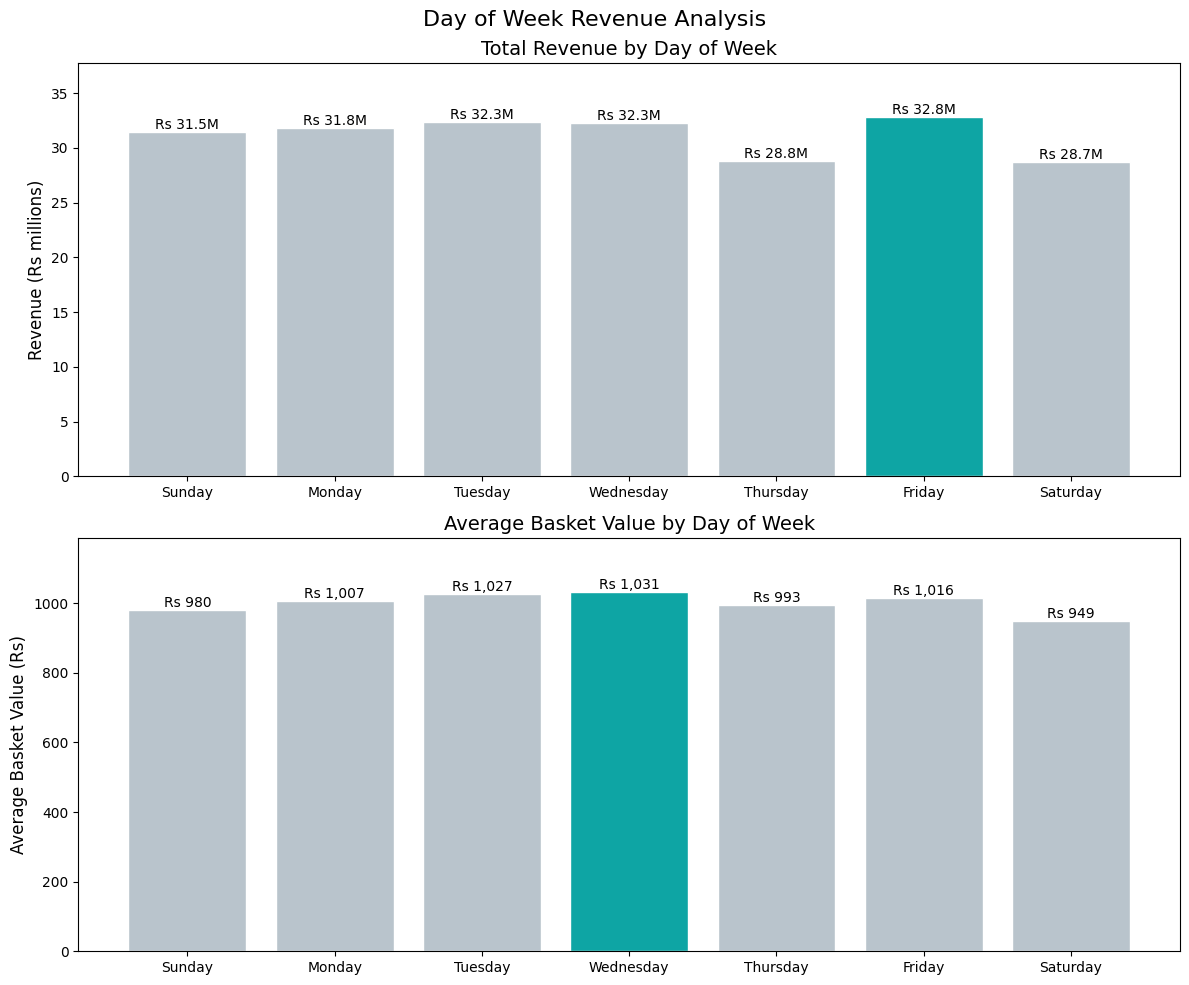

Chart 11 saved!


In [14]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df['day_of_week'] = df['date'].dt.day_name()

day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

baskets_by_day = df.groupby('invoice_no').agg(
    basket_value=('total_amount', 'sum'),
    day_of_week=('day_of_week', 'first')
)

revenue_by_day = df.groupby('day_of_week')['total_amount'].sum().reindex(day_order)
transactions_by_day = baskets_by_day['day_of_week'].value_counts().reindex(day_order)
avg_basket_by_day = baskets_by_day.groupby('day_of_week')['basket_value'].mean().reindex(day_order)

print("DAY OF WEEK SUMMARY")
print("=" * 70)
print(f"{'Day':<12}{'Revenue (Rs)':>18}{'Transactions':>15}{'Avg Basket (Rs)':>18}")
for day in day_order:
    print(f"{day:<12}{revenue_by_day[day]:>18,.0f}{transactions_by_day[day]:>15,}{avg_basket_by_day[day]:>18,.2f}")

busiest_day = revenue_by_day.idxmax()
highest_basket_day = avg_basket_by_day.idxmax()
print()
print(f"Highest revenue day: {busiest_day} (Rs {revenue_by_day.max():,.0f})")
print(f"Highest average basket day: {highest_basket_day} (Rs {avg_basket_by_day.max():,.2f})")

brand_color = '#0EA5A4'
muted_color = '#B9C4CC'

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

colors_top = [brand_color if d == busiest_day else muted_color for d in day_order]
bars = axes[0].bar(day_order, revenue_by_day.values / 1e6, color=colors_top, edgecolor='white')
for bar, val in zip(bars, revenue_by_day.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'Rs {val / 1e6:.1f}M', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Total Revenue by Day of Week', fontsize=14)
axes[0].set_ylabel('Revenue (Rs millions)', fontsize=12)
axes[0].set_ylim(0, revenue_by_day.max() / 1e6 * 1.15)

colors_bottom = [brand_color if d == highest_basket_day else muted_color for d in day_order]
bars = axes[1].bar(day_order, avg_basket_by_day.values, color=colors_bottom, edgecolor='white')
for bar, val in zip(bars, avg_basket_by_day.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'Rs {val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Average Basket Value by Day of Week', fontsize=14)
axes[1].set_ylabel('Average Basket Value (Rs)', fontsize=12)
axes[1].set_ylim(0, avg_basket_by_day.max() * 1.15)

fig.suptitle('Day of Week Revenue Analysis', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart11_day_of_week.png'), dpi=150)
plt.show()
print("Chart 11 saved!")

### Finding: Chart 11 - Day of Week Revenue Analysis

Revenue is spread fairly evenly across the week, with about a 14% gap between the quietest and busiest day, but the pattern is still useful. Friday is the busiest day with Rs 32.8 million in total revenue and 32,290 transactions, closely followed by Tuesday (Rs 32.3 million) and Wednesday (Rs 32.3 million). Wednesday has the highest average basket value at Rs 1,031.33, so midweek shoppers buy the largest baskets. Saturday, the weekly holiday in Nepal, is the quietest day by both revenue (Rs 28.7 million) and average basket (Rs 949.09), and Thursday is similarly slow (Rs 28.8 million). Sunday, the first working day, brings many shoppers (32,096 transactions, the second highest count) but with smaller baskets (Rs 980.13 on average).

For staffing, the store needs its fullest counter coverage and most frequent shelf restocking on Friday, and strong coverage on Sunday when transaction count is high. For promotional timing, cross-sell offers built from the association rules are best run Tuesday to Friday, when baskets are already large and an extra suggested item is most likely to be added. Saturday and Thursday are the natural days for footfall promotions designed to pull extra customers into the store.

In [15]:
import os

figures = os.listdir(figures_path)
print(f"Charts saved: {len(figures)}")
for f in sorted(figures):
    print(f"  {f}")

Charts saved: 28
  chart10_abc_analysis.png
  chart10_elbow_method.png
  chart10_network_graph.png
  chart11_day_of_week.png
  chart11_silhouette_scores.png
  chart12_store_planogram.png
  chart13_revenue_impact.png
  chart14_before_after_layout.png
  chart15_monthly_trends.png
  chart16_algorithm_comparison.png
  chart17_product_rules_scatter.png
  chart18_product_cooccurrence_heatmap.png
  chart19_monthly_revenue_trend.png
  chart1_top20_products_count.png
  chart20_linear_regression_forecast.png
  chart21_prophet_forecast.png
  chart22_crosssell_before_after.png
  chart23_basket_classifier_features.png
  chart24_model_comparison.png
  chart2_category_distribution.png
  chart3_top20_products_revenue.png
  chart4_basket_value_distribution.png
  chart5_items_per_basket.png
  chart6_categories_per_basket.png
  chart7_category_cooccurrence_heatmap.png
  chart8_top_product_pairs.png
  chart9_association_rules_scatter.png
  chart9_basket_segmentation.png


## EDA Complete

### Key Findings

1. FOOD STAPLES is the anchor category, appearing in 42.19% of all baskets (91,988 of 218,037) and accounting for 23.34% of all line items sold. It should be placed centrally so customers pass other products on the way to it.
2. Mean basket value is Rs 1,000.81 and median is Rs 500.00. Increasing the median is our primary KPI target.
3. Most customers buy 3 to 4 products per visit. Products that are bought together must be placed close together because customers are not browsing the full store.
4. Kalo Dal and Rato Dal are bought together 3,989 times. This is the strongest product pair and they must be adjacent on the shelf.
5. CLEANING SUPPLIES appears as a connector category across many pairs. This makes it a strong candidate for a central placement zone.
6. Revenue leaders and frequency leaders are not the same products. Placement strategy must balance both.
7. The co-occurrence heatmap in Chart 7 directly drives the placement zone design in notebook 07.

### Next Step: 04_transaction_encoding.ipynb